In [1]:
# ============================================================
# NBA Players Points Prediction
# Machine Learning Model: Decision Tree Regressor
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [2]:
# Load the preprocessed dataset

df = pd.read_csv("nba_preprocessed.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully
Dataset shape: (9067, 11)


,Game_Date,Team,Player,MP,PTS,TRB,AST,FGA,FG%,STL,TOV
0,20251101,25,113,1.830533,2.048740,-0.015845,0.208047,1.805808,0.293646,-0.78218,0.508793
1,20251101,25,494,1.582544,2.273030,-0.015845,-0.177476,1.470112,0.059664,0.22981,-0.910007
2,20251101,25,117,1.418808,1.488015,0.283463,1.750142,0.798719,0.672273,1.24180,1.218193
3,20251101,25,127,1.404501,1.488015,2.677930,1.364618,0.798719,0.672273,0.22981,1.218193
4,20251101,25,143,-1.636546,-0.979176,-0.913770,-0.948523,-1.215461,2.310152,-0.78218,-0.910007


In [3]:
# Check dataset information

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Description:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9067 entries, 0 to 9066
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Game_Date  9067 non-null   int64  
 1   Team       9067 non-null   int64  
 2   Player     9067 non-null   int64  
 3   MP         9067 non-null   float64
 4   PTS        9067 non-null   float64
 5   TRB        9067 non-null   float64
 6   AST        9067 non-null   float64
 7   FGA        9067 non-null   float64
 8   FG%        9067 non-null   float64
 9   STL        9067 non-null   float64
 10  TOV        9067 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 779.3 KB
None

Missing Values:
Game_Date    0
Team         0
Player       0
MP           0
PTS          0
TRB          0
AST          0
FGA          0
FG%          0
STL          0
TOV          0
dtype: int64

Dataset Description:


,Game_Date,Team,Player,MP,PTS,TRB,AST,FGA,FG%,STL,TOV
count,9.067000e+03,9067.000000,9067.000000,9.067000e+03,9.067000e+03,9.067000e+03,9.067000e+03,9.067000e+03,9.067000e+03,9.067000e+03,9.067000e+03
mean,2.025116e+07,14.610566,251.856182,1.057938e-16,9.795725e-20,1.020715e-16,-9.296143e-17,5.779478e-18,-9.834908e-17,7.797397e-17,-1.018755e-17
std,5.147320e+01,8.624990,142.544476,1.000055e+00,1.000055e+00,1.000055e+00,1.000055e+00,1.000055e+00,1.000055e+00,1.000055e+00,1.000055e+00
min,2.025110e+07,0.000000,0.000000,-2.118217e+00,-1.203466e+00,-1.213079e+00,-9.485231e-01,-1.383309e+00,-1.944080e+00,-7.821798e-01,-9.100069e-01
25%,2.025111e+07,7.000000,128.000000,-7.153296e-01,-7.548855e-01,-6.144619e-01,-5.629996e-01,-7.119158e-01,-5.274205e-01,-7.821798e-01,-9.100069e-01
50%,2.025113e+07,15.000000,255.000000,9.460936e-02,-1.941604e-01,-3.151535e-01,-1.774760e-01,-2.083710e-01,0.000000e+00,-7.821798e-01,-2.006068e-01
75%,2.025122e+07,22.000000,375.000000,8.067833e-01,5.908547e-01,5.827715e-01,5.935710e-01,6.308703e-01,5.361376e-01,2.298099e-01,5.087933e-01
max,2.025123e+07,29.000000,497.000000,2.868591e+00,5.076655e+00,6.269630e+00,5.990900e+00,6.169863e+00,2.310152e+00,7.313738e+00,5.474594e+00


In [4]:
# Define target variable

target = "PTS"

# Features = all columns except PTS
X = df.drop(target, axis=1)

# Target = PTS
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print(target)

Features:
['Game_Date', 'Team', 'Player', 'MP', 'TRB', 'AST', 'FGA', 'FG%', 'STL', 'TOV']

Target Variable:
PTS


In [5]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (7253, 10)
Testing data shape: (1814, 10)


In [6]:
# Create baseline Decision Tree model

baseline_dt = DecisionTreeRegressor(
    random_state=42
)

# Train the model
baseline_dt.fit(X_train, y_train)

# Make predictions
baseline_predictions = baseline_dt.predict(X_test)

print("Baseline Decision Tree model trained successfully")

Baseline Decision Tree model trained successfully


In [7]:
# Evaluate baseline model

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_mse = mean_squared_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline Decision Tree Evaluation")
print("---------------------------------")
print("MAE:", baseline_mae)
print("MSE:", baseline_mse)
print("RMSE:", baseline_rmse)
print("R2 Score:", baseline_r2)


Baseline Decision Tree Evaluation
---------------------------------
MAE: 0.2496988543350054
MSE: 0.13019524937754584
RMSE: 0.36082578812710414
R2 Score: 0.8672006691833553


In [8]:
# Create improved Decision Tree model

dt_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

print("Improved Decision Tree model trained successfully")

Improved Decision Tree model trained successfully


In [9]:
# Evaluate improved model

mae = mean_absolute_error(y_test, dt_predictions)
mse = mean_squared_error(y_test, dt_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, dt_predictions)

print("Improved Decision Tree Evaluation")
print("---------------------------------")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Improved Decision Tree Evaluation
---------------------------------
MAE: 0.21351947664393534
MSE: 0.09039447047086423
RMSE: 0.30065673195666887
R2 Score: 0.9077975176095323


In [10]:
# Compare actual and predicted values

comparison_df = pd.DataFrame({
    "Actual PTS": y_test.values,
    "Predicted PTS": dt_predictions
})

comparison_df.head(20)


,Actual PTS,Predicted PTS
0,2.273030,1.421908
1,-0.642740,-0.928781
2,-0.194160,-0.469249
3,1.151580,1.587578
4,0.478710,0.854096
5,0.142275,-0.173220
6,0.590855,0.313743
7,-0.642740,-0.469249
8,-1.203466,-1.182812
9,1.375870,0.854096


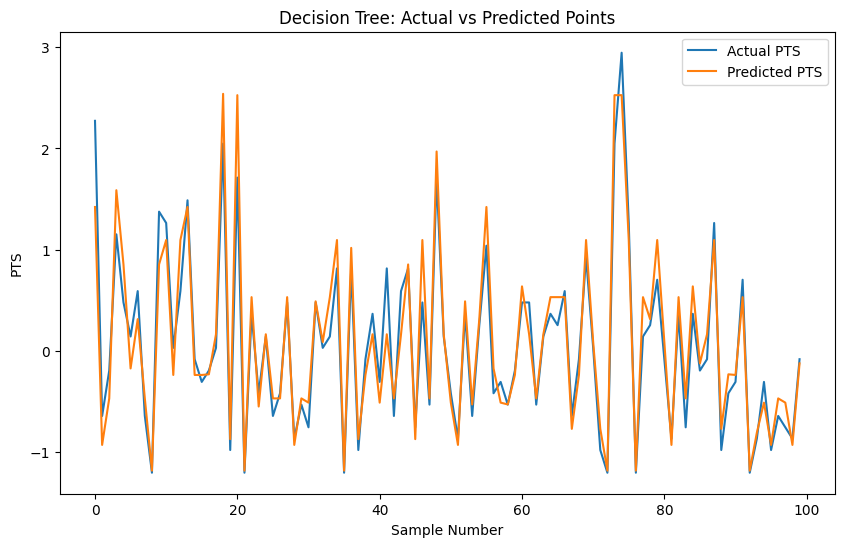

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(y_test.values[:100], label="Actual PTS")
plt.plot(dt_predictions[:100], label="Predicted PTS")

plt.title("Decision Tree: Actual vs Predicted Points")
plt.xlabel("Sample Number")
plt.ylabel("PTS")
plt.legend()
plt.show()

In [12]:
# Get feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,FGA,0.856590
7,FG%,0.143152
3,MP,0.000258
0,Game_Date,0.000000
1,Team,0.000000
2,Player,0.000000
5,AST,0.000000
4,TRB,0.000000
8,STL,0.000000
9,TOV,0.000000


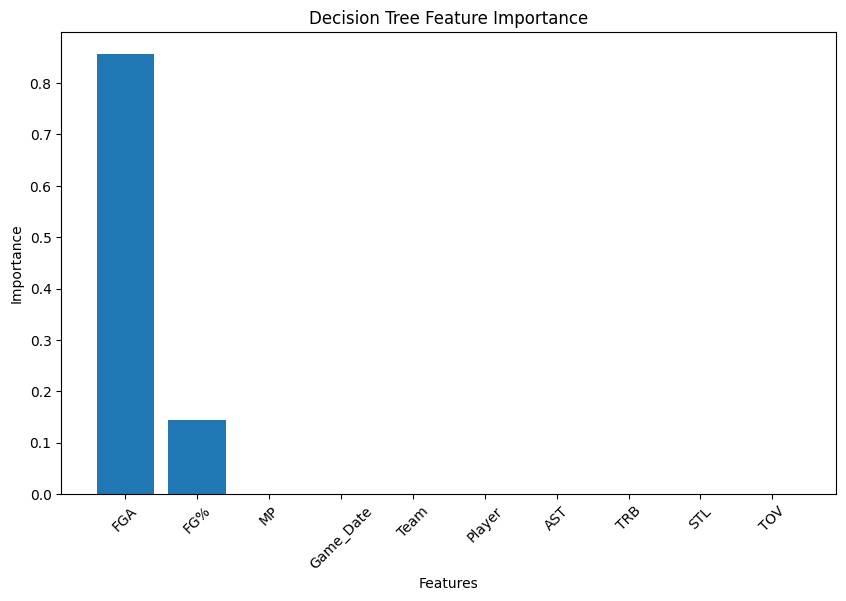

In [13]:
plt.figure(figsize=(10, 6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

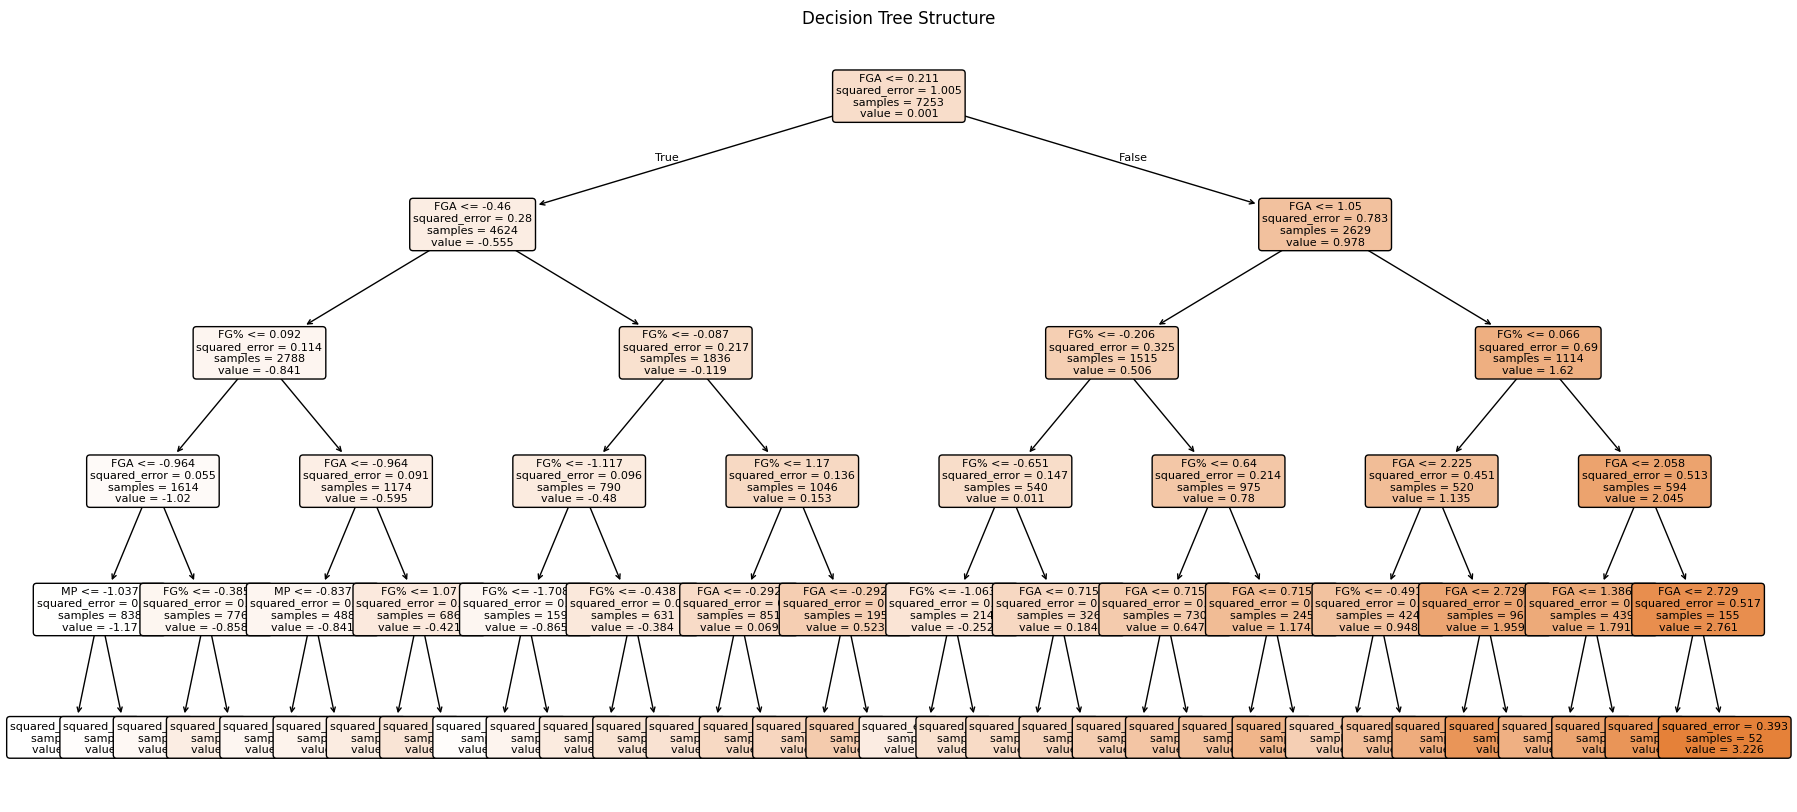

In [14]:
plt.figure(figsize=(22, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Structure")
plt.show()

In [15]:
# Compare training and testing scores

train_score = dt_model.score(X_train, y_train)
test_score = dt_model.score(X_test, y_test)

print("Training Score:", train_score)
print("Testing Score:", test_score)

if train_score > test_score + 0.15:
    print("The model may be overfitting.")
else:
    print("The model generalizes well.")

Training Score: 0.9115427176814668
Testing Score: 0.9077975176095323
The model generalizes well.


In [16]:
depths = [2, 3, 4, 5, 6, 7, 8, 10]

train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

depth_results = pd.DataFrame({
    "Max Depth": depths,
    "Training R2": train_scores,
    "Testing R2": test_scores
})

depth_results

,Max Depth,Training R2,Testing R2
0,2,0.728542,0.707505
1,3,0.829862,0.827620
2,4,0.886802,0.888416
3,5,0.911543,0.907798
4,6,0.930439,0.920618
5,7,0.940726,0.923315
6,8,0.949222,0.918590
7,10,0.966220,0.903026


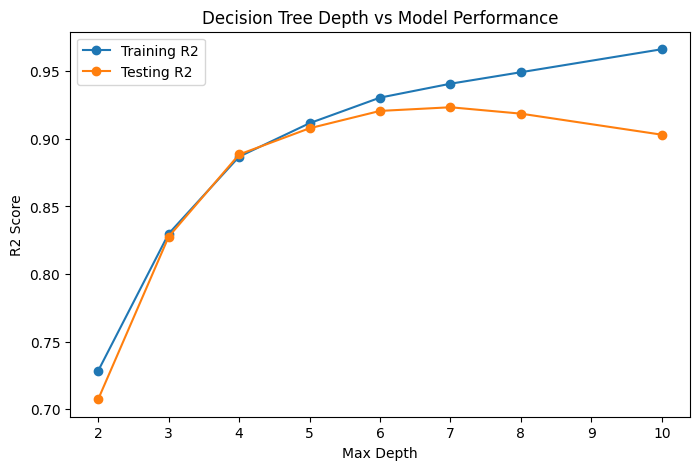

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(depths, train_scores, marker='o', label="Training R2")
plt.plot(depths, test_scores, marker='o', label="Testing R2")

plt.title("Decision Tree Depth vs Model Performance")
plt.xlabel("Max Depth")
plt.ylabel("R2 Score")
plt.legend()
plt.show()

In [18]:
# Cross validation

cv_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Cross Validation Score:", cv_scores.mean())

Cross Validation Scores:
[0.91491938 0.91025349 0.90391737 0.90785793 0.91152224]

Average Cross Validation Score: 0.9096940829830734


In [19]:
# Grid Search for best Decision Tree parameters

param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}

Best Cross Validation Score:
0.925464252107693


In [20]:
# Best model from GridSearchCV

best_dt_model = grid_search.best_estimator_

# Predict using best model
best_predictions = best_dt_model.predict(X_test)

print("Best Decision Tree model selected successfully")

Best Decision Tree model selected successfully


In [21]:
best_mae = mean_absolute_error(y_test, best_predictions)
best_mse = mean_squared_error(y_test, best_predictions)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, best_predictions)

print("Best Decision Tree Model Evaluation")
print("-----------------------------------")
print("MAE:", best_mae)
print("MSE:", best_mse)
print("RMSE:", best_rmse)
print("R2 Score:", best_r2)

Best Decision Tree Model Evaluation
-----------------------------------
MAE: 0.18922591226079044
MSE: 0.07509423108253792
RMSE: 0.2740332663793539
R2 Score: 0.9234037825217959


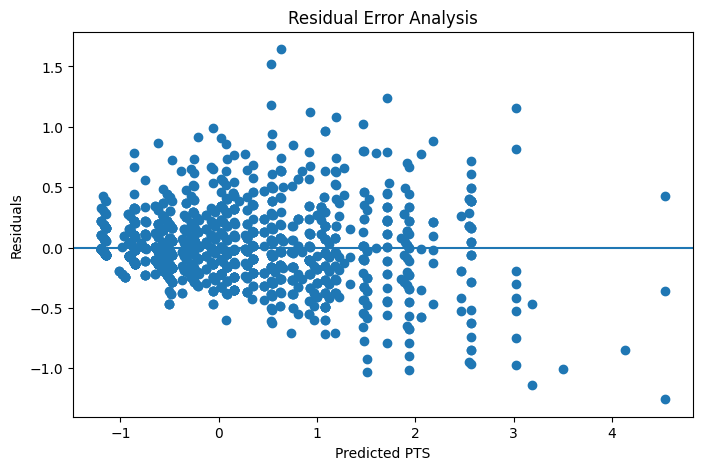

In [22]:
# Residuals = actual - predicted

residuals = y_test - best_predictions

plt.figure(figsize=(8, 5))

plt.scatter(best_predictions, residuals)
plt.axhline(y=0)

plt.title("Residual Error Analysis")
plt.xlabel("Predicted PTS")
plt.ylabel("Residuals")
plt.show()

In [23]:
# Save the trained model

joblib.dump(best_dt_model, "decision_tree_pts_model.pkl")

print("Decision Tree model saved successfully")

Decision Tree model saved successfully


In [24]:
print("Final Decision Tree Summary")
print("---------------------------")
print("Model: Decision Tree Regressor")
print("Target Variable: PTS")
print("Best Parameters:", grid_search.best_params_)

print("\nFinal Evaluation:")
print("MAE:", best_mae)
print("MSE:", best_mse)
print("RMSE:", best_rmse)
print("R2 Score:", best_r2)

print("\nTop Important Features:")
print(feature_importance.head())

Final Decision Tree Summary
---------------------------
Model: Decision Tree Regressor
Target Variable: PTS
Best Parameters: {'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}

Final Evaluation:
MAE: 0.18922591226079044
MSE: 0.07509423108253792
RMSE: 0.2740332663793539
R2 Score: 0.9234037825217959

Top Important Features:
     Feature  Importance
6        FGA    0.856590
7        FG%    0.143152
3         MP    0.000258
0  Game_Date    0.000000
1       Team    0.000000
